In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import bootstrap

fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [3]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [4]:
%run env_tom.py
%run run.py connect

2024-09-24 14:42:26,651::INFO::settings.py::Setting loglevel to INFO
2024-09-24 14:42:26,657::INFO::settings.py::Setting stores to {}
2024-09-24 14:42:26,669::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-09-24 14:42:26,670::INFO::settings.py::Setting database.misc.create_tables to True
2024-09-24 14:42:26,670::INFO::settings.py::Setting enable_python_native_blobs to True
2024-09-24 14:42:26,671::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-09-24 14:42:26,671::INFO::settings.py::Setting database.user to thomas
2024-09-24 14:42:26,672::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-09-24 14:42:27,352::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-09-24 14:42:27,416::INFO::table.py::could not log event in table ~log
2024-09-24 14:42:27,754::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
from vr4mice.analysis import regression
vdf.get_rc_params()

In [6]:
dual_occuder = [
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]

In [7]:

def get_all_in_list(data_set_list, training_stage="dual_occluder"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        df = dlc.SyncDLCWGame().get_data(key =  d)
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    big_df =  pd.concat(big_df).reset_index()
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    first_n_samples =5
    big_df["norm_x"] = big_df.groupby("trial", as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
    big_df["norm_y"] = big_df.groupby("trial", as_index=False)["y"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
        
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    big_df ["trial_number_max"] = big_df.groupby(["mouse_name", "date", "dataset"], as_index=False)["trial"].transform(
        lambda x: x.max()
    )
    
    right_reward_x = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["x"].mean()
    right_reward_z = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["y"].mean()
    
    big_df["distance_to_reward"] = (np.array(((right_reward_x - big_df["x"] * big_df["flip_one_side"]) ** 2),dtype=np.float64) + 
                                    np.array(((right_reward_z - big_df["y"]) ** 2), dtype=np.float64))
    big_df ["heading_dir"] = ((big_df.heading_dir - 90) + 180) % 360 - 180
    big_df ["head_dir"] = ((big_df.head_dir) + 180) % 360 -180
    big_df = big_df.infer_objects()
    #big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    #big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))

In [8]:
big_df = get_all_in_list(data_set_list = dual_occuder)

dual_occluder
['Pheasant', '2024-08-20', '1']
['Pheasant', '2024-08-21', '1']


In [9]:
big_df

,index,dataset,step,step_time,trial,reward,x,y,bins_y,norm_y,...,head_angle_acceleration,heading_dir_acceleration,mouse_name,session,date,training_stage,session_increment,norm_x,trial_number_max,distance_to_reward
0,2,Pheasant_2024-08-20_1,1006.0,13.867053,2,0.0,9.130847,-9.355945,None,-0.581754,...,-145.243978,29.438209,Pheasant,Pheasant_2024-08-20_1,2024-08-20,dual_occluder,1,0.299169,250,950.556729
1,3,Pheasant_2024-08-20_1,1007.5,13.887053,2,0.0,8.830198,-8.779781,None,-0.005590,...,-86.092253,13.754545,Pheasant,Pheasant_2024-08-20_1,2024-08-20,dual_occluder,1,-0.001481,250,922.280702
2,4,Pheasant_2024-08-20_1,1009.0,13.907052,2,0.0,8.546350,-8.090948,None,0.683243,...,214.391612,-84.590979,Pheasant,Pheasant_2024-08-20_1,2024-08-20,dual_occluder,1,-0.285328,250,888.149822
3,5,Pheasant_2024-08-20_1,1010.5,13.927053,2,0.0,8.014088,-7.086484,None,1.687707,...,344.016054,-109.299205,Pheasant,Pheasant_2024-08-20_1,2024-08-20,dual_occluder,1,-0.817590,250,842.717803
4,6,Pheasant_2024-08-20_1,1012.0,13.948051,2,0.0,7.764617,-6.271815,None,2.502376,...,-54.518772,-0.107496,Pheasant,Pheasant_2024-08-20_1,2024-08-20,dual_occluder,1,-1.067061,250,804.007088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21917,11444,Pheasant_2024-08-21_1,176615.0,2382.030534,250,0.0,15.272628,20.880139,None,19.419071,...,-62.680469,-17.068580,Pheasant,Pheasant_2024-08-21_1,2024-08-21,dual_occluder,2,19.182517,250,7.905402
21918,11445,Pheasant_2024-08-21_1,176616.5,2382.050037,250,0.0,16.342392,20.963053,None,19.501984,...,-14.785297,12.377305,Pheasant,Pheasant_2024-08-21_1,2024-08-21,dual_occluder,2,20.252281,250,3.351182
21919,11446,Pheasant_2024-08-21_1,176618.0,2382.070535,250,0.0,16.574588,20.979596,None,19.518527,...,37.042191,58.956336,Pheasant,Pheasant_2024-08-21_1,2024-08-21,dual_occluder,2,20.484477,250,2.664452
21920,11447,Pheasant_2024-08-21_1,176619.5,2382.090534,250,0.0,17.545746,21.036036,None,19.574967,...,-136.733155,40.577275,Pheasant,Pheasant_2024-08-21_1,2024-08-21,dual_occluder,2,21.455635,250,0.944641


(0.0, 200.0)

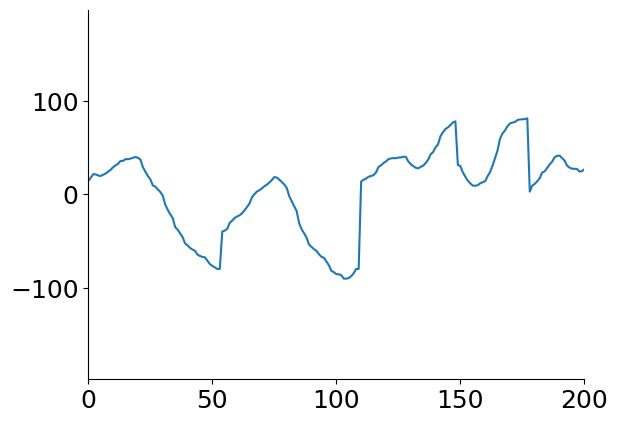

In [10]:
plt.plot(big_df.heading_dir)
plt.xlim(0,200)

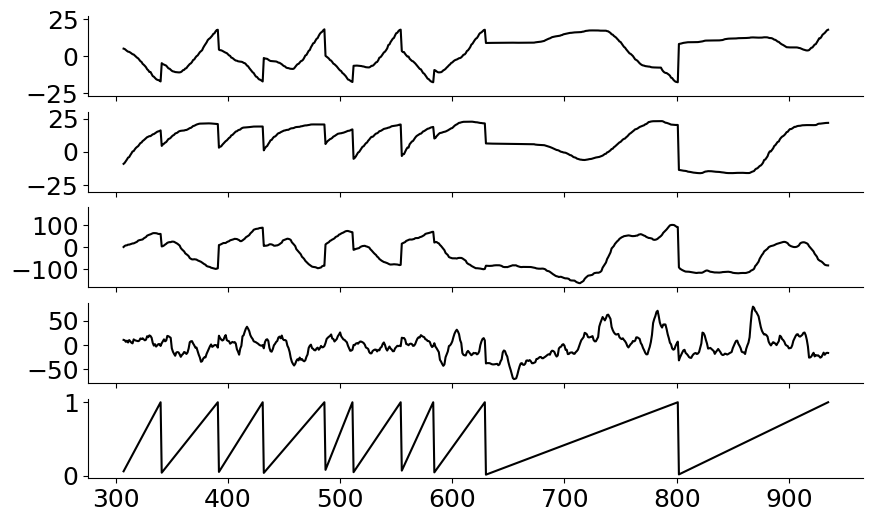

In [11]:
fig, ax = plt.subplots(5,1, figsize = (10,6), sharex=True)
trial =  big_df [(big_df.session == big_df.session.unique()[0]) & (big_df.trial.isin(range(10,20)))].copy()
trial ["trial_length"] = trial.groupby(["trial"],as_index=False)["trial_step"].transform(lambda x: x/x.max())
ax[0].plot(trial.x, c="black")
ax[0].set_ylim(-27,27)
ax[1].plot(trial.y, c="black")
ax[1].set_ylim(-30,30)
ax[2].plot(trial.heading_dir,c="black")
ax[2].set_ylim(-180,180)
ax[3].plot(trial.head_angle, c="black")
ax[4].plot(trial.trial_length, c="black")

plt.savefig(fig_save_path + "behavioural_var_traces.svg", transparent=True)



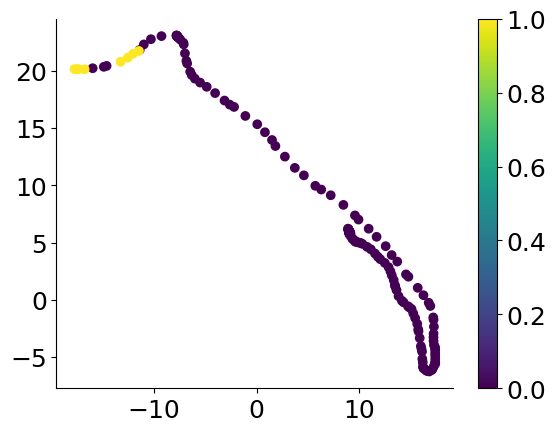

In [54]:
trial =  big_df [(big_df.session == big_df.session.unique()[0]) & (big_df.trial.isin([18]))].copy()
trial ["trial_length"] = trial.groupby(["trial"],as_index=False)["trial_step"].transform(lambda x: x/x.max())
plt.scatter(trial.x, trial.y, c=(trial.heading_dir < 100) & (trial.heading_dir > 75))
plt.colorbar()

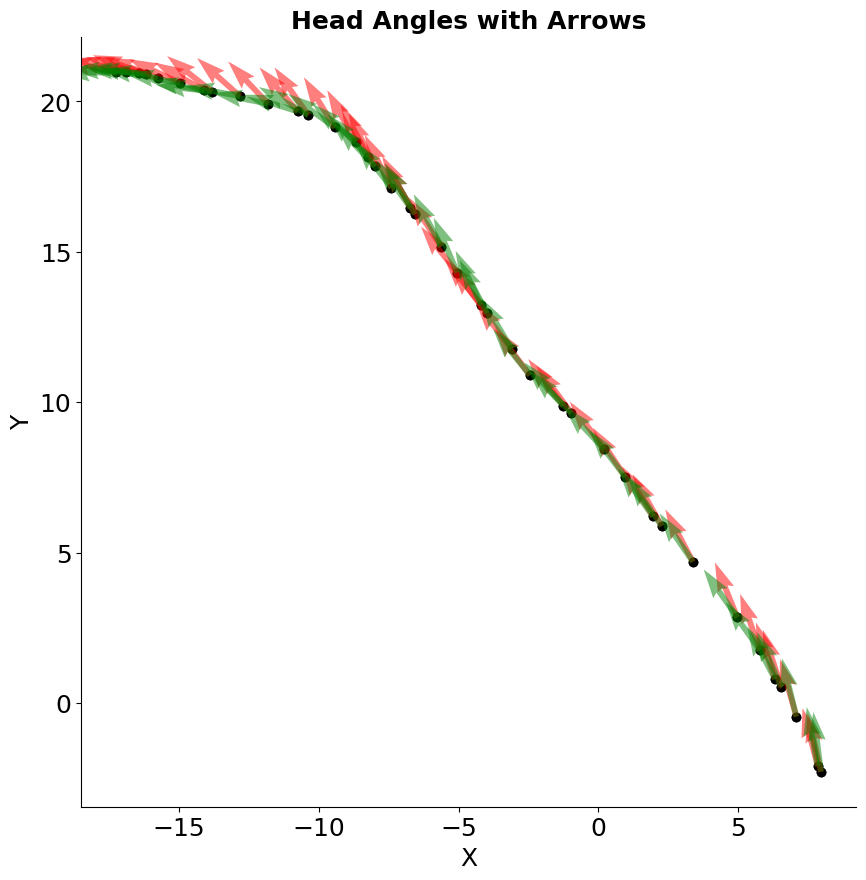

In [46]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize =(10,10))
# Subset the data
trial = big_df[(big_df.session == big_df.session.unique()[0]) & (big_df.trial.isin([4]))].copy()
trial["trial_length"] = trial.groupby(["trial"], as_index=False)["trial_step"].transform(lambda x: x/x.max())

# Create the scatter plot
plt.scatter(trial.x, trial.y, c="black")


# Calculate arrow components for head angle (assuming the angle is in radians)
arrow_length = 2  # Adjust the length of the arrows as needed
dx = arrow_length * np.cos(np.deg2rad(trial.heading_dir+90)) # X component of the arrow
dy = arrow_length * np.sin(np.deg2rad(trial.heading_dir+90))  # Y component of the arrow

dx_h = arrow_length * np.cos(np.deg2rad(trial.heading_dir +90)+np.deg2rad(trial.head_angle)) # X component of the arrow
dy_h = arrow_length * np.sin(np.deg2rad(trial.heading_dir+90)+np.deg2rad(trial.head_angle))
plt.scatter(trial.x, trial.y, c="black")

# Add arrows (quiver) to the plot
plt.quiver(trial.x, trial.y, dx, dy, angles='xy', scale_units='xy', scale=1, color='red', alpha=0.5)

plt.quiver(trial.x, trial.y, dx_h, dy_h, angles='xy', scale_units='xy', scale=1, color='green', alpha=0.5)

# Show the plot
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Head Angles with Arrows')
plt.show()

